In [ ]:
# Install dependencies
!pip install pydub soundfile
!apt-get install -y ffmpeg
!pip install transformers
!pip install audiomentations
!pip install pandas

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import librosa
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
from pydub import AudioSegment
import soundfile as sf

print("Dependencies installed and imported.")

Dependencies installed and imported.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kartikeybartwal/speech-content-fluency-and-pronunciation-scores")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/speech-content-fluency-and-pronunciation-scores


In [ ]:
!mv /kaggle/input/speech-content-fluency-and-pronunciation-scores /content

In [4]:
# Convert audio files to .wav
def convert_to_wav(input_path, output_path):
    try:
        audio = AudioSegment.from_file(input_path)
        audio.export(output_path, format="wav")
        return output_path
    except Exception as e:
        print(f"Error converting {input_path}: {e}")
        return None

audio_path = os.path.join('/content', '2', 'speech_data', 'audio onepte-repeat sentence')
wav_path = os.path.join('/content', 'wav_files')
os.makedirs(wav_path, exist_ok=True)

for audio_file in os.listdir(audio_path):
    if audio_file.endswith(('.m4a', '.mp3')):
        input_file = os.path.join(audio_path, audio_file)
        output_file = os.path.join(wav_path, audio_file.rsplit('.', 1)[0] + '.wav')
        convert_to_wav(input_file, output_file)

print(f"Audio files converted to WAV in {wav_path}")

Audio files converted to WAV in /content/wav_files


In [5]:
print(len(os.listdir('/content/wav_files')))

436


In [6]:
import pandas as pd

file_path = "/content/2/processed_audio_sample_scoring.xlsx"
data = pd.read_excel(file_path)
data.head()

,Unnamed: 0,Record Audio Name,Content,Pronun,Fluency,feature_vector
0,0,audio_beb45dff-f264-43c5-b051-61dab6a3b2a1,18,11,25,NaN
1,1,audio_f86da9b5-9ed2-4153-9508-e59448e7d8bc,70,53,64,NaN
2,2,audio_0e7cded9-1569-4202-98f8-59f88384437b,54,40,51,NaN
3,3,audio_08bf8a53-1e31-4d82-8979-b53a14baa196,28,14,36,NaN
4,4,audio_a3b474a9-3b8e-4533-aa95-0cda51f1395d,16,11,25,NaN


In [7]:
df = data.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['Content'])
df.head()

,Record Audio Name,Pronun,Fluency,feature_vector
0,audio_beb45dff-f264-43c5-b051-61dab6a3b2a1,11,25,NaN
1,audio_f86da9b5-9ed2-4153-9508-e59448e7d8bc,53,64,NaN
2,audio_0e7cded9-1569-4202-98f8-59f88384437b,40,51,NaN
3,audio_08bf8a53-1e31-4d82-8979-b53a14baa196,14,36,NaN
4,audio_a3b474a9-3b8e-4533-aa95-0cda51f1395d,11,25,NaN


In [8]:
import pandas as pd
import numpy as np
import os

# Paths (update if different)
wav_path = '/content/wav_files'  # Directory with WAV files

# Step 1: Verify dataset exists
if 'df' not in globals():
    raise ValueError("Dataset 'df' not found. Ensure Sections 1–4 have been run.")

# Step 2: Print initial dataset statistics
print("Initial Dataset Statistics:")
print(df[['Pronun', 'Fluency']].describe())
print(f"Initial dataset size: {len(df)}")

# Step 3: Define function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Step 4: Detect outliers in Pronun and Fluency
pronun_outliers, pronun_lower, pronun_upper = detect_outliers_iqr(df, 'Pronun')
fluency_outliers, fluency_lower, fluency_upper = detect_outliers_iqr(df, 'Fluency')

# Step 5: Combine outliers using Record Audio Name
outlier_names = pd.concat([pronun_outliers, fluency_outliers])['Record Audio Name'].drop_duplicates()

# Step 6: Print outlier summary
print("\nOutlier Detection Summary:")
print(f"Pronun - Lower Bound: {pronun_lower:.2f}, Upper Bound: {pronun_upper:.2f}")
print(f"Fluency - Lower Bound: {fluency_lower:.2f}, Upper Bound: {fluency_upper:.2f}")
print(f"Number of Pronun outliers: {len(pronun_outliers)}")
print(f"Number of Fluency outliers: {len(fluency_outliers)}")
print(f"Total unique outlier rows: {len(outlier_names)}")

if len(outlier_names) > 0:
    print("\nOutlier Rows (to be removed):")
    print(df[df['Record Audio Name'].isin(outlier_names)][['Record Audio Name', 'Pronun', 'Fluency']])
else:
    print("\nNo outliers detected. No rows will be removed.")

# Step 7: Remove outliers from df
df_clean = df[~df['Record Audio Name'].isin(outlier_names)].reset_index(drop=True)
print(f"\nDataset size after removing outliers: {len(df_clean)}")

# Step 8: Remove rows with missing audio files
missing_files = df_clean[~df_clean['Record Audio Name'].apply(lambda x: os.path.exists(os.path.join(wav_path, f"{x}.wav")))]
if len(missing_files) > 0:
    print("\nRemoving rows with missing audio files:")
    print(missing_files[['Record Audio Name', 'Pronun', 'Fluency']])
    df_clean = df_clean[~df_clean['Record Audio Name'].isin(missing_files['Record Audio Name'])].reset_index(drop=True)
    print(f"Dataset size after removing missing files: {len(df_clean)}")
else:
    print("\nAll rows have corresponding audio files.")

# Step 9: Update df
df = df_clean

# Step 10: Print final dataset statistics
print("\nFinal Dataset Statistics (after removing outliers and missing files):")
print(df[['Pronun', 'Fluency']].describe())

# Step 11: Verify outlier removal
if len(outlier_names) > 0:
    removed_outliers = df[df['Record Audio Name'].isin(outlier_names)]
    if len(removed_outliers) == 0:
        print("\nVerified: All outlier rows successfully removed.")
    else:
        print("\nWarning: Some outlier rows remain:")
        print(removed_outliers[['Record Audio Name', 'Pronun', 'Fluency']])

Initial Dataset Statistics:
            Pronun     Fluency
count   410.000000  410.000000
mean     48.453659   56.653659
std     109.959446   30.781461
min      10.000000   10.000000
25%      22.250000   41.000000
50%      44.000000   59.000000
75%      62.000000   72.000000
max    2224.000000  548.000000
Initial dataset size: 410

Outlier Detection Summary:
Pronun - Lower Bound: -37.38, Upper Bound: 121.62
Fluency - Lower Bound: -5.50, Upper Bound: 118.50
Number of Pronun outliers: 1
Number of Fluency outliers: 1
Total unique outlier rows: 2

Outlier Rows (to be removed):
                              Record Audio Name  Pronun  Fluency
254  audio_4013fcb7-f033-4541-a706-2f5006b5dca8    2224       66
365  audio_5acc7326-7c78-44ff-af05-d3f33b80b10f      38      548

Dataset size after removing outliers: 408

Removing rows with missing audio files:
                             Record Audio Name  Pronun  Fluency
75  audio_7d03cdc7-3532-4037-af13-a1eb6d9eObc9      14       30
77  audio_dd6

In [9]:
df.head()

,Record Audio Name,Pronun,Fluency,feature_vector
0,audio_beb45dff-f264-43c5-b051-61dab6a3b2a1,11,25,NaN
1,audio_f86da9b5-9ed2-4153-9508-e59448e7d8bc,53,64,NaN
2,audio_0e7cded9-1569-4202-98f8-59f88384437b,40,51,NaN
3,audio_08bf8a53-1e31-4d82-8979-b53a14baa196,14,36,NaN
4,audio_a3b474a9-3b8e-4533-aa95-0cda51f1395d,11,25,NaN


In [10]:
# Scale Pronun and Fluency to 1–10
def scale_to_1_10(values, min_val, max_val):
    # Linearly scale values from [min_val, max_val] to [1, 10]
    return 1 + ((values - min_val) / (max_val - min_val)) * 9


df['Pronun'] = scale_to_1_10(df['Pronun'], min(df['Pronun']), max(df['Pronun']))
df['Fluency'] = scale_to_1_10(df['Fluency'], min(df['Fluency']), max(df['Fluency']))

# Verify scaled ranges
print("Scaled target ranges (1–10):")
print(df[['Pronun', 'Fluency']].describe())

Scaled target ranges (1–10):
           Pronun     Fluency
count  402.000000  402.000000
mean     5.233235    6.477313
std      2.808549    2.261871
min      1.000000    1.000000
25%      2.647887    4.840000
50%      5.309859    6.880000
75%      7.591549    8.440000
max     10.000000   10.000000


In [11]:
df.head()

,Record Audio Name,Pronun,Fluency,feature_vector
0,audio_beb45dff-f264-43c5-b051-61dab6a3b2a1,1.126761,2.80,NaN
1,audio_f86da9b5-9ed2-4153-9508-e59448e7d8bc,6.450704,7.48,NaN
2,audio_0e7cded9-1569-4202-98f8-59f88384437b,4.802817,5.92,NaN
3,audio_08bf8a53-1e31-4d82-8979-b53a14baa196,1.507042,4.12,NaN
4,audio_a3b474a9-3b8e-4533-aa95-0cda51f1395d,1.126761,2.80,NaN


In [12]:
import os
import numpy as np
import pandas as pd
import librosa

SAMPLE_RATE = 22050
HOP_LENGTH = 512
SEGMENT_DURATION = 5  # in seconds
MAX_FRAMES = int((SEGMENT_DURATION * SAMPLE_RATE) / HOP_LENGTH)
print("Expected MFCC frames:", MAX_FRAMES)  # ~215

Expected MFCC frames: 215


In [20]:
import librosa
from audiomentations import Compose, AddGaussianNoise, PitchShift

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.3),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.3)
])

def extract_mfcc(file_path, min_duration=2.0, max_frames=215, silence_threshold=-40):
    """Extract MFCCs and detect silence using RMS energy."""
    try:
        audio, sr = librosa.load(file_path, sr=22050)  # Ensure sample rate is consistent
        duration = librosa.get_duration(y=audio, sr=sr)

        segments = []
        if duration < min_duration:
            return None  # Skip very short audios
        else:
            num_segments = int(np.ceil(duration / 5))  # 5-second segments
            for i in range(num_segments):
                start = int(i * 5 * sr)
                end = int(start + 5 * sr)
                segment = audio[start:end]
                segment = augmenter(segment, sample_rate=sr)

                # Pad the last segment if needed
                if len(segment) < 5 * sr:
                    padding = int(5 * sr - len(segment))
                    segment = np.pad(segment, (0, padding))

                # Calculate RMS energy to detect silence
                rms = librosa.feature.rms(y=segment)
                avg_db = 20 * np.log10(np.mean(rms) + 1e-9)  # Avoid log(0)
                is_silent = avg_db < silence_threshold

                # Extract MFCCs only if not silent
                if not is_silent:
                    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13, hop_length=512)
                    if mfcc.shape[1] > max_frames:
                        mfcc = mfcc[:, :max_frames]
                    else:
                        mfcc = np.pad(mfcc, ((0, 0), (0, max_frames - mfcc.shape[1])), mode='constant')

                    mfcc = mfcc.T
                    segments.append(mfcc)
        return segments  # Returns only non-silent MFCC segments
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

In [21]:
from pydub import AudioSegment
import numpy as np

def is_silent(segment, threshold=20):
    """Check if a segment is mostly silent."""
    audio = AudioSegment(
        segment.tobytes(),
        frame_rate=SAMPLE_RATE,
        sample_width=segment.dtype.itemsize,
        channels=1
    )
    return audio.dBFS < threshold  # Adjust threshold as needed

# Extract MFCC segments (automatically skips silent ones)
df['feature_vector'] = df['Record Audio Name'].apply(
    lambda x: extract_mfcc(os.path.join(wav_path, f"{x}.wav"))
)

# Explode into one row per segment
df = df.explode('feature_vector').reset_index(drop=True)
df = df[df['feature_vector'].notna()]  # Remove failed/empty extractions

print("Filtered segments (non-silent):", len(df))

Filtered segments (non-silent): 853


In [24]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 682
Test size: 171


In [25]:
from sklearn.preprocessing import StandardScaler

def prepare_features(df):
    features = np.array(df['feature_vector'].tolist())
    n_samples, n_frames, n_feats = features.shape
    return features.reshape(-1, n_feats), (n_samples, n_frames, n_feats)

# Extract & scale
X_train_2d, train_shape = prepare_features(train_df)
X_test_2d, test_shape = prepare_features(test_df)

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Back to 3D
X_train = X_train_scaled_2d.reshape(train_shape)
X_test = X_test_scaled_2d.reshape(test_shape)

y_train_pronun = train_df['Pronun'].values
y_train_fluency = train_df['Fluency'].values
y_test_pronun = test_df['Pronun'].values
y_test_fluency = test_df['Fluency'].values


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers

def build_model(input_shape=(215, 13)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, kernel_size=3, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)

    pronun_output = layers.Dense(1, name='pronun_output')(x)
    fluency_output = layers.Dense(1, name='fluency_output')(x)

    return Model(inputs=inputs, outputs=[pronun_output, fluency_output])

model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss={'pronun_output': 'mse', 'fluency_output': 'mse'},
    loss_weights={'pronun_output': 0.6, 'fluency_output': 0.4},
    metrics={'pronun_output': 'mae', 'fluency_output': 'mae'}
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 215, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 213, 32)   │      1,280 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 106, 32)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3392)      │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │    217,152 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pronun_output       │ (None, 1)         │         65 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fluency_output      │ (None, 1)         │         65 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 218,562 (853.76 KB)

 Trainable params: 218,562 (853.76 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    {'pronun_output': y_train_pronun, 'fluency_output': y_train_fluency},
    epochs=100,
    batch_size=32,
    validation_data=(X_test, [y_test_pronun, y_test_fluency]),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - fluency_output_loss: 15.0448 - fluency_output_mae: 3.1213 - loss: 15.0823 - pronun_output_loss: 15.1074 - pronun_output_mae: 3.2264 - val_fluency_output_loss: 9.4798 - val_fluency_output_mae: 2.6696 - val_loss: 9.7974 - val_pronun_output_loss: 9.5802 - val_pronun_output_mae: 2.6621
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - fluency_output_loss: 5.6326 - fluency_output_mae: 1.9489 - loss: 6.2181 - pronun_output_loss: 6.6050 - pronun_output_mae: 2.1771 - val_fluency_output_loss: 6.7360 - val_fluency_output_mae: 2.0376 - val_loss: 7.7224 - val_pronun_output_loss: 8.4742 - val_pronun_output_mae: 2.4462
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - fluency_output_loss: 4.0140 - fluency_output_mae: 1.6128 - loss: 5.0362 - pronun_output_loss: 5.7150 - pronun_output_mae: 2.0397 - val_fluency_output_loss: 5.3429 - val_fluency_output_mae: 1.9522 - val_loss: 6.8031 - val_pronun_output_loss: 7.5108 - val_pronun_output_mae: 2.

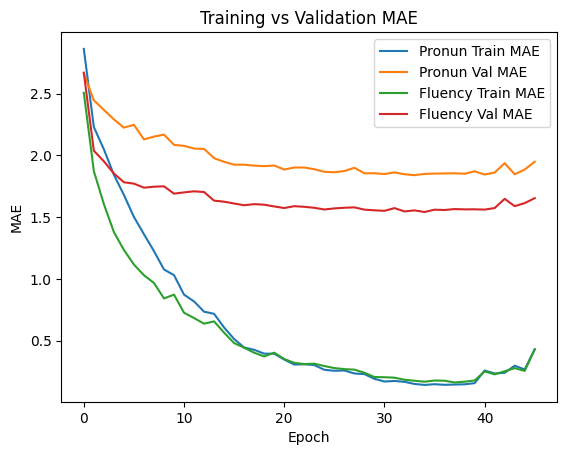

In [28]:
import matplotlib.pyplot as plt

# Plot MAE over epochs
plt.plot(history.history['pronun_output_mae'], label='Pronun Train MAE')
plt.plot(history.history['val_pronun_output_mae'], label='Pronun Val MAE')
plt.plot(history.history['fluency_output_mae'], label='Fluency Train MAE')
plt.plot(history.history['val_fluency_output_mae'], label='Fluency Val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.show()

In [29]:

# Print sample predictions
y_pred_pronun, y_pred_fluency = model.predict(X_test)
for i in range(5):
    print(f"Sample {i+1}:")
    print(f"  Actual Pronun: {y_test_pronun[i]}, Predicted: {y_pred_pronun[i][0]:.2f}")
    print(f"  Actual Fluency: {y_test_fluency[i]}, Predicted: {y_pred_fluency[i][0]:.2f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Sample 1:
  Actual Pronun: 1.0, Predicted: 2.19
  Actual Fluency: 1.48, Predicted: 4.17
Sample 2:
  Actual Pronun: 4.676056338028169, Predicted: 4.69
  Actual Fluency: 5.8, Predicted: 5.92
Sample 3:
  Actual Pronun: 1.0, Predicted: 2.54
  Actual Fluency: 2.2, Predicted: 4.52
Sample 4:
  Actual Pronun: 3.028169014084507, Predicted: 1.83
  Actual Fluency: 4.48, Predicted: 3.52
Sample 5:
  Actual Pronun: 8.47887323943662, Predicted: 8.05
  Actual Fluency: 7.4799999999999995, Predicted: 7.82


In [32]:
import joblib

model.save("Fluency and Pronunciation Rating model.keras")

joblib.dump(scaler, "mfcc_scaler.pkl")

['mfcc_scaler.pkl']

In [ ]:
from tensorflow.keras.models import load_model
import librosa
import soundfile as sf

def predict_audio_rating(file_path):
    # Convert to WAV
    if not file_path.endswith(".wav"):
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        wav_path = "converted.wav"
        sf.write(wav_path, y, sr)
        file_path = wav_path

    model = load_model("Fluency and Pronunciation Rating model.keras", compile=False)
    scaler = joblib.load("mfcc_scaler.pkl")

    segments = extract_mfcc(file_path)
    if not segments:
        return "No usable speech found."

    X = np.array(segments)
    X_2d = X.reshape(-1, 13)
    X_scaled = scaler.transform(X_2d).reshape(len(X), 215, 13)

    pronun_preds, fluency_preds = model.predict(X_scaled)

    # Use top 25% scores
    top_n = max(1, int(0.25 * len(pronun_preds)))
    avg_pronun = np.mean(sorted(pronun_preds.flatten())[-top_n:])
    avg_fluency = np.mean(sorted(fluency_preds.flatten())[-top_n:])

    return {
        "Pronunciation Score": round(avg_pronun, 2),
        "Fluency Score": round(avg_fluency, 2)
    }

# Usage:
result = predict_audio_rating("motivation.mp3")
print(result)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
{'Pronunciation Score': 8.24, 'Fluency Score': 9.33}
